In [2]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(SeuratDisk)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(hise)
quiet_library(H5weaver)
quiet_library(eulerr)
quiet_library(gridExtra)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 1, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [3]:
wd <- "/home/workspace/IFN/Batch7" 
setwd(wd)


In [ ]:
# Filter for relevant batch 7 files and read-in as Seurat object

In [32]:
meta <- fread(file.path("/home/workspace/IFN", "IFN_stim_sample_sheet.csv"))
meta_select <- meta %>% 
                filter(BatchID == "EXP-00756" & Description %in% c("Fresh", "culture_IFNa", "culture_no_stim")) 

In [43]:
regex <- meta_select$SampleID %>% paste(collapse = "|")
files <- list.files("cache", full.names = T, pattern = regex)

In [15]:
h5_list <- lapply(files, function(x){
    open <- read_h5_seurat(x)
    open
})

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input 

In [16]:
so <- merge(h5_list[[1]], h5_list[2:length(h5_list)]) 

In [17]:
so@meta.data <- left_join(so@meta.data, meta, by = c("sampleID" = "SampleID"))
rownames(so@meta.data) <- so$barcodes

### Normalization + Clustering

In [18]:
so <- so %>% 
            NormalizeData() %>%
            FindVariableFeatures() %>%
            ScaleData() %>%
            RunPCA(verbose = FALSE) %>%
            FindNeighbors(dims = 1:30) %>%
            FindClusters(resolution = 0.8, verbose = FALSE) %>%
            RunUMAP(dims = 1:30)

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
19:15:14 UMAP embedding parameters a = 0.9922 b = 1.112

19:15:14 Read 339399 rows and found 30 numeric columns

19:15:14 Using Annoy for neighbor search, n_neighbors = 30

19:15:14 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:16:17 Writing NN index file to temp file /tmp/RtmpQJs5e2/fileabe8d6fbaaa64

19:16:17 Searching Annoy index using 1 thread, search_k = 3000

19:19:24 Annoy recall = 100%

19:19:

In [ ]:
# save initial version of object
so %>% saveRDS(file.path(wd, "Batch7_so.rds"))

In [46]:
# save as H5AD for Scrublet
SaveH5Seurat(so, file.path(wd, glue("Batch7.h5seurat")))
Convert(file.path(wd, glue("Batch7.h5seurat")), dest = "h5ad")

Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

Adding scale.data for RNA

Adding variable features for RNA

Adding feature-level metadata for RNA

Adding cell embeddings for pca

Adding loadings for pca

No projected loadings for pca

Adding standard deviations for pca

No JackStraw data for pca

Adding cell embeddings for umap

No loadings for umap

No projected loadings for umap

No standard deviations for umap

No JackStraw data for umap

Validating h5Seurat file

Adding scale.data from RNA as X

Transfering meta.features to var

Adding data from RNA as raw

Transfering meta.features to raw/var

Transfering meta.data to obs

Adding dimensional reduction information for pca

Adding feature loadings for pca

Adding dimensional reduction information for umap



In [26]:
so <- readRDS(file.path(wd, "Batch7_so.rds"))

### Inspect doublets

In [27]:
doublets <- fread(file.path('/home/workspace/IFN/', "Scrublet", "scrublet_sample_doublet_calls_batch7.csv"))

In [30]:
so@meta.data <- so@meta.data %>% 
                    left_join(doublets %>% select(barcode, predicted_doublet), by = c("barcodes" = "barcode"))
rownames(so@meta.data) <- so$barcodes

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



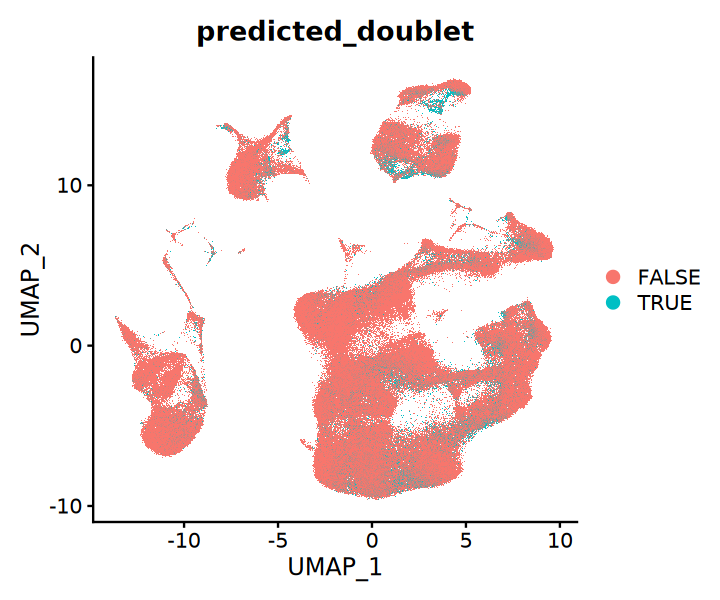

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



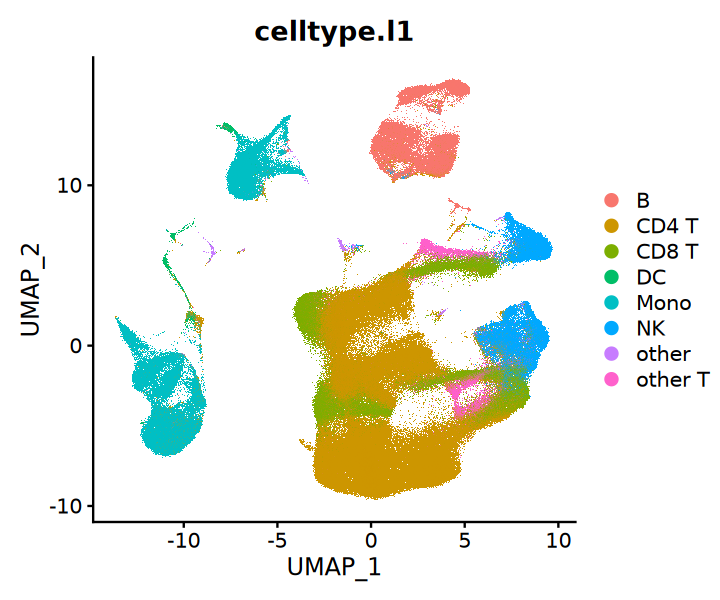

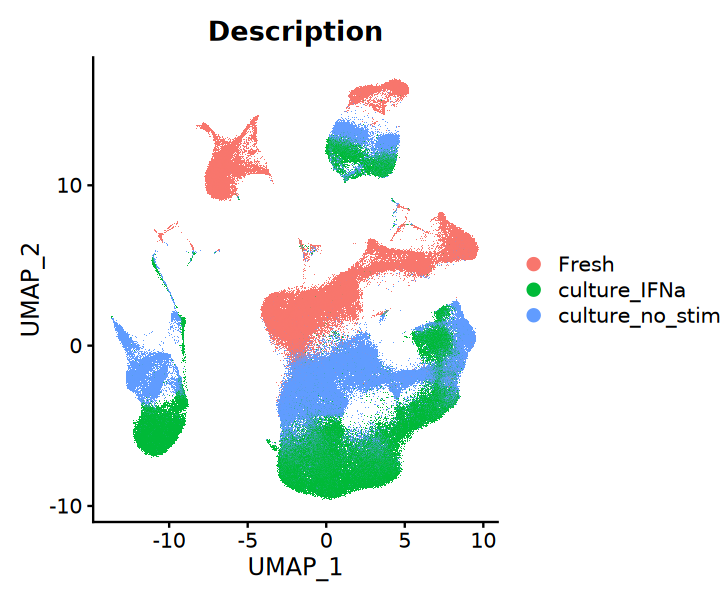

In [38]:
fig.size(5,6)
DimPlot(so, group.by = "predicted_doublet")
DimPlot(so, group.by = "celltype.l1")
DimPlot(so, group.by = "Description")

In [33]:
so %>% 
    subset(predicted_doublet == FALSE) %>%
    saveRDS(file.path(wd, glue("Batch7_so_cleaned_v2.rds")))

In [47]:
so <- readRDS(file.path(wd, glue("Batch7_so_cleaned_v2.rds")))

[1] "/home/workspace/IFN/Batch7"

### Visualize donor densities

In [ ]:
##### Per-group density plots from seurat object
plotDensity <- function(so,
                        col, # grouping column
                        bins = 100,
                        ncol = NULL
    ){
    groups <- so@meta.data[,col] %>% as.character() %>% unique()
    orig_embed <- data.frame(so@reductions$umap@cell.embeddings)
    
    ggs <- lapply(groups, function(i){
        sub <- subset(so, !!sym(col) == i)

        ggplot(data.frame(sub@reductions$umap@cell.embeddings), aes(x = UMAP_1, y = UMAP_2)) +
          geom_bin_2d(bins=bins) +
          theme_classic() +
          scale_fill_continuous(type = "viridis") + 
            theme(legend.position = 'none') + 
            ggtitle(i) + 
            theme(plot.title = element_text(size =15)) + 
            xlim(min(orig_embed$UMAP_1) - 1, max(orig_embed$UMAP_1) + 1) + 
            ylim(min(orig_embed$UMAP_2) - 1, max(orig_embed$UMAP_2) + 1)
    })
    gridExtra::grid.arrange(grobs = ggs, ncol = ncol)

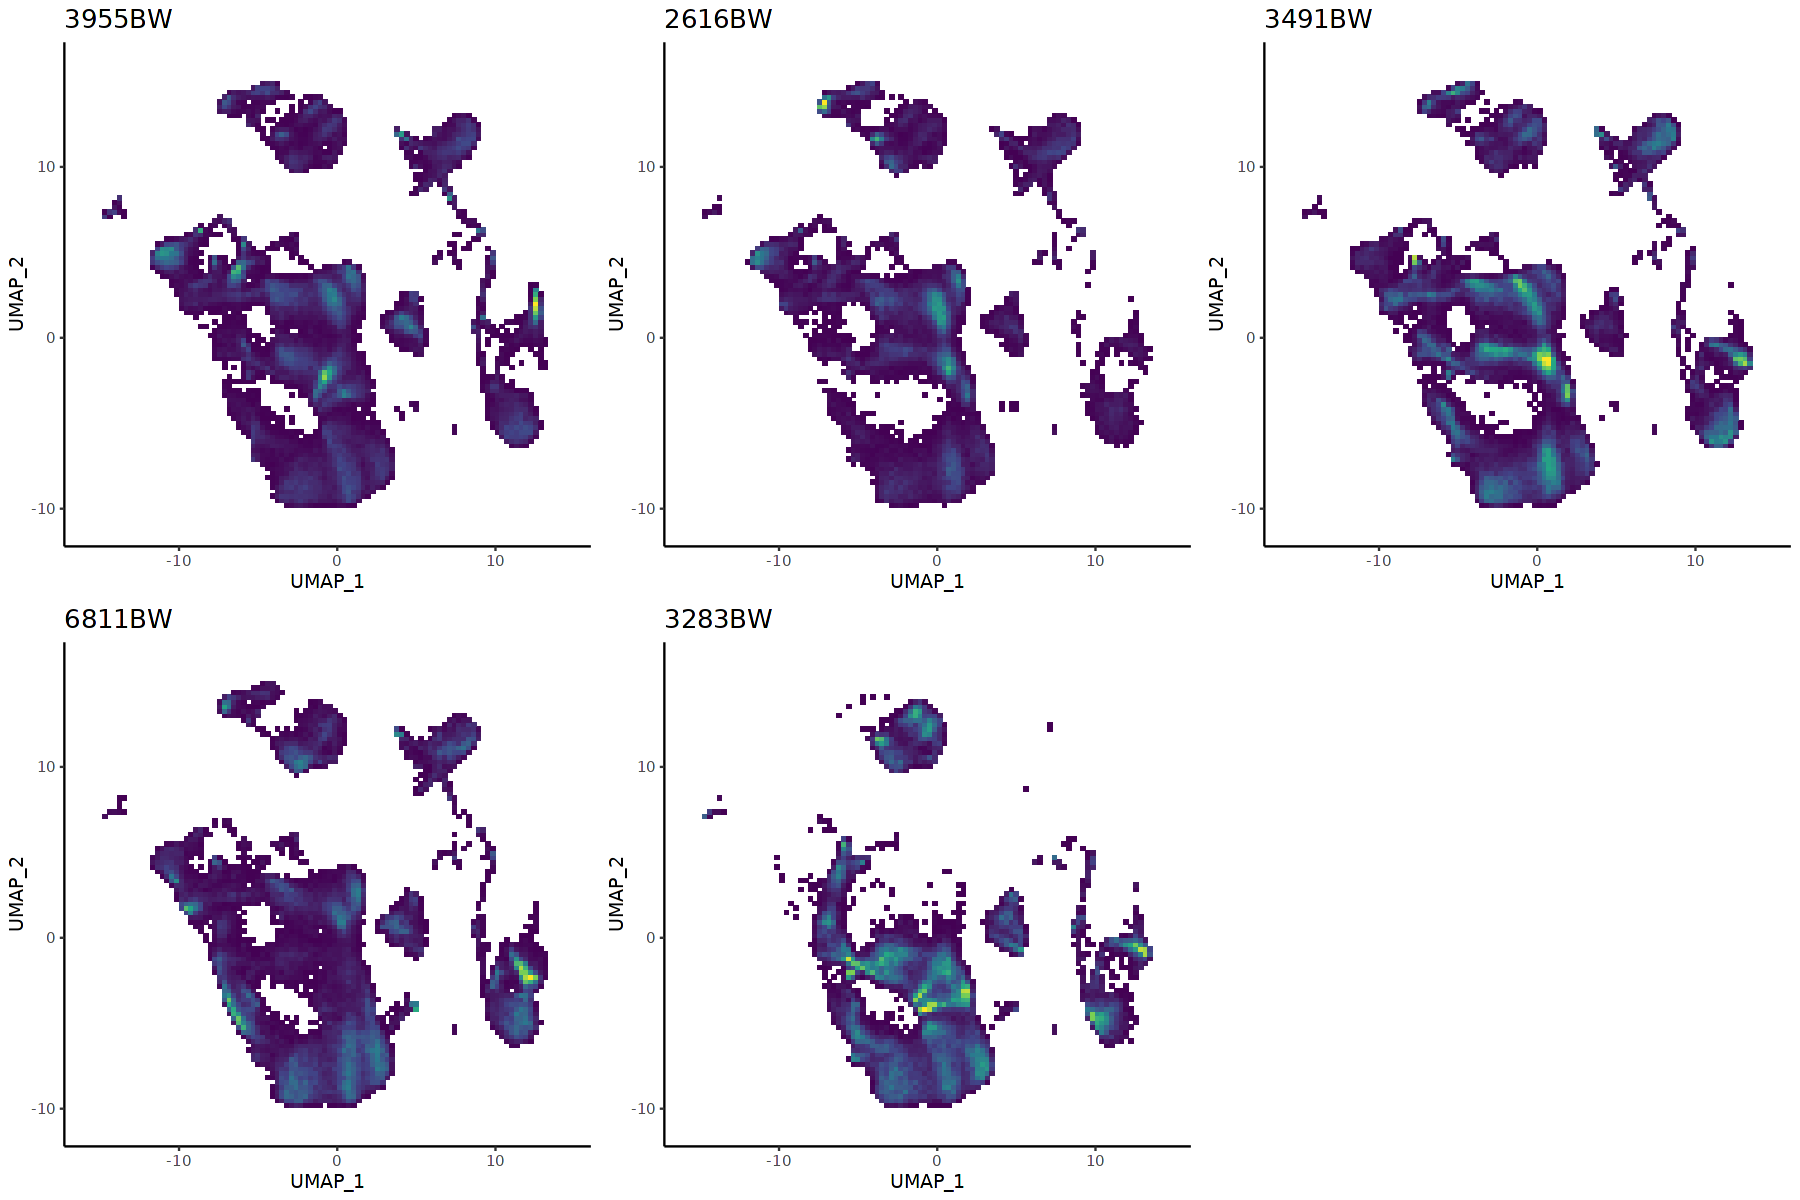

In [127]:
fig.size(10,15)
plotDensity(so, "DonorID", ncol = 3)  